In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Configuration
OUTPUT_DIR = "outputs/surrogates/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LR_PATH = os.path.join(OUTPUT_DIR, "logistic_regression_classification_predictions.csv")
DT_CLASS_PATH = os.path.join(OUTPUT_DIR, "decision_tree_classification_predictions.csv")
RIDGE_PATH = os.path.join(OUTPUT_DIR, "ridge_regression_probability_predictions.csv")
DT_REG_PATH = os.path.join(OUTPUT_DIR, "decision_tree_regressor_probability_predictions.csv")

In [4]:
lr_df = pd.read_csv(LR_PATH)
dt_class_df = pd.read_csv(DT_CLASS_PATH)
ridge_df = pd.read_csv(RIDGE_PATH)
dt_reg_df = pd.read_csv(DT_REG_PATH)

print("Logistic Regression:", lr_df.shape)
print("Decision Tree Classifier:", dt_class_df.shape)
print("Ridge Regression:", ridge_df.shape)
print("Decision Tree Regressor:", dt_reg_df.shape)

Logistic Regression: (120, 7)
Decision Tree Classifier: (120, 7)
Ridge Regression: (120, 7)
Decision Tree Regressor: (120, 7)


In [5]:
assert lr_df["image_id"].tolist() == dt_class_df["image_id"].tolist()
assert lr_df["image_id"].tolist() == ridge_df["image_id"].tolist()
assert lr_df["image_id"].tolist() == dt_reg_df["image_id"].tolist()

assert np.allclose(
    lr_df["cnn_probability_tb"],
    ridge_df["cnn_probability_tb"]
)

print("All surrogate prediction files are correctly aligned.")

All surrogate prediction files are correctly aligned.


In [6]:
classification_ensemble = lr_df[
    ["image_id",
    "image_path",
    "true_label",
    "cnn_prediction",
    "cnn_probability_tb"
    ]
].copy()

classification_ensemble["lr_probability_tb"] = (
    lr_df["logistic_regression_probability_tb"]
)

classification_ensemble["dt_probability_tb"] = (
    dt_class_df["decision_tree_probability_tb"]
)

# Equal-weight soft voting
classification_ensemble["ensemble_probability_tb"] = (
    classification_ensemble["lr_probability_tb"] +
    classification_ensemble["dt_probability_tb"]
) / 2.0

classification_ensemble["ensemble_prediction"] = (
    classification_ensemble["ensemble_probability_tb"] >= 0.5
).astype(int)

classification_ensemble.head()

,image_id,image_path,true_label,cnn_prediction,cnn_probability_tb,lr_probability_tb,dt_probability_tb,ensemble_probability_tb,ensemble_prediction
0,CHNCXR_0516_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.999988,1.000000,1.0,1.000000,1
1,CHNCXR_0399_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.999902,1.000000,1.0,1.000000,1
2,CHNCXR_0012_0,/user/HS401/mn01409/Documents/Dissertation/dat...,0,0,0.154945,0.000783,0.0,0.000391,0
3,CHNCXR_0530_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.999917,1.000000,1.0,1.000000,1
4,CHNCXR_0601_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.954714,0.999468,1.0,0.999734,1


In [7]:
y_cnn = classification_ensemble["cnn_prediction"]
y_ensemble = classification_ensemble["ensemble_prediction"]
ensemble_prob = classification_ensemble["ensemble_probability_tb"]

classification_metrics = {
    "model": "classification_ensemble",
    "fidelity_accuracy": accuracy_score(y_cnn, y_ensemble),
    "fidelity_precision": precision_score(
        y_cnn,
        y_ensemble,
        zero_division=0
    ),
    "fidelity_recall": recall_score(
        y_cnn,
        y_ensemble,
        zero_division=0
    ),
    "fidelity_f1": f1_score(
        y_cnn,
        y_ensemble,
        zero_division=0
    ),
    "fidelity_auc": roc_auc_score(
        y_cnn,
        ensemble_prob
    )
}

classification_metrics_df = pd.DataFrame(
    [classification_metrics]
)

classification_metrics_df

,model,fidelity_accuracy,fidelity_precision,fidelity_recall,fidelity_f1,fidelity_auc
0,classification_ensemble,0.925,0.942308,0.890909,0.915888,0.993007


## Probability Surrogate Ensembles

In [8]:
probability_ensemble = ridge_df[
    [
        "image_id",
        "image_path",
        "true_label",
        "cnn_prediction",
        "cnn_probability_tb"
    ]
].copy()

probability_ensemble["ridge_probability_tb"] = (
    ridge_df["ridge_regression_probability_tb"]
)

probability_ensemble["dt_regressor_probability_tb"] = (
    dt_reg_df["decision_tree_regressor_probability_tb"]
)

# Equal-weight ensemble
probability_ensemble["ensemble_probability_tb"] = (
    probability_ensemble["ridge_probability_tb"] +
    probability_ensemble["dt_regressor_probability_tb"]
) / 2.0

# Ensure probabilities remain valid
probability_ensemble["ensemble_probability_tb"] = (
    probability_ensemble["ensemble_probability_tb"]
    .clip(0.0, 1.0)
)
probability_ensemble.head()

,image_id,image_path,true_label,cnn_prediction,cnn_probability_tb,ridge_probability_tb,dt_regressor_probability_tb,ensemble_probability_tb
0,CHNCXR_0516_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.999988,1.000000,0.995338,0.997669
1,CHNCXR_0399_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.999902,1.000000,0.995338,0.997669
2,CHNCXR_0012_0,/user/HS401/mn01409/Documents/Dissertation/dat...,0,0,0.154945,0.317886,0.024715,0.171300
3,CHNCXR_0530_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.999917,1.000000,0.995338,0.997669
4,CHNCXR_0601_1,/user/HS401/mn01409/Documents/Dissertation/dat...,1,1,0.954714,0.827821,0.995338,0.911579


In [9]:
cnn_prob = probability_ensemble["cnn_probability_tb"]
ensemble_prob = probability_ensemble["ensemble_probability_tb"]

mae = mean_absolute_error(
    cnn_prob,
    ensemble_prob
)

mse = mean_squared_error(
    cnn_prob,
    ensemble_prob
)

rmse = np.sqrt(mse)
r2 = r2_score(
    cnn_prob,
    ensemble_prob
)

correlation = np.corrcoef(
    cnn_prob,
    ensemble_prob
)[0, 1]

probability_metrics = {
    "model": "probability_ensemble",
    "probability_mae": mae,
    "probability_mse": mse,
    "probability_rmse": rmse,
    "probability_r2": r2,
    "probability_correlation": correlation
}

probability_metrics_df = pd.DataFrame(
    [probability_metrics]
)
probability_metrics_df

,model,probability_mae,probability_mse,probability_rmse,probability_r2,probability_correlation
0,probability_ensemble,0.082843,0.01925,0.138745,0.897633,0.947571


In [10]:
classification_ensemble.to_csv(
    os.path.join(OUTPUT_DIR, "surrogate_classification_ensemble_predictions.csv"),
    index=False
)

classification_metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "surrogate_classification_ensemble_fidelity.csv"),index=False)

probability_ensemble.to_csv(
    os.path.join(OUTPUT_DIR, "surrogate_probability_ensemble_predictions.csv"),index=False)

probability_metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "surrogate_probability_ensemble_fidelity.csv"),index=False)

print("Ensemble results saved successfully.")

Ensemble results saved successfully.


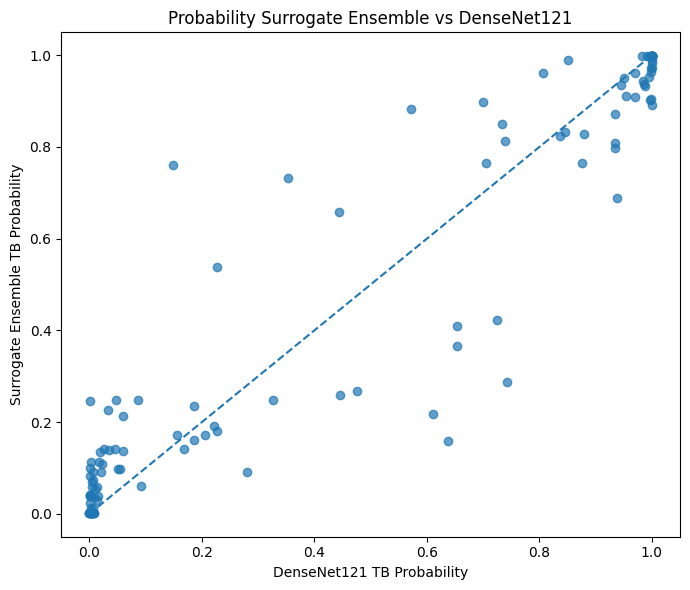

In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(
    probability_ensemble["cnn_probability_tb"],
    probability_ensemble["ensemble_probability_tb"],
    alpha=0.7
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("DenseNet121 TB Probability")
plt.ylabel("Surrogate Ensemble TB Probability")
plt.title(
    "Probability Surrogate Ensemble vs DenseNet121"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "surrogate_probability_ensemble.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [12]:
individual_probability_metrics = pd.DataFrame([
    {
        "model": "Ridge Regression",
        "MAE": 0.112913582,
        "RMSE": 0.162668845,
        "R2": 0.859286610,
        "Correlation": 0.934369821
    },
    {
        "model": "Decision Tree Regressor",
        "MAE": 0.095750946,
        "RMSE": 0.192270270,
        "R2": 0.803414750,
        "Correlation": 0.913994575
    },
    {
        "model": "Surrogate Ensemble",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Correlation": correlation
    }
])

individual_probability_metrics

,model,MAE,RMSE,R2,Correlation
0,Ridge Regression,0.112914,0.162669,0.859287,0.934370
1,Decision Tree Regressor,0.095751,0.192270,0.803415,0.913995
2,Surrogate Ensemble,0.082843,0.138745,0.897633,0.947571


In [14]:
individual_probability_metrics.to_csv(
    os.path.join(OUTPUT_DIR, "surrogate_probability_ensemble_comparison.csv"),
    index=False
)

In [15]:
individual_classification_metrics = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "Accuracy": 0.983333333,
        "Precision": 0.964912281,
        "Recall": 1,
        "F1": 0.982142857,
        "AUC": 0.09972027297
    },
    {
        "model": "Decision Tree Classifier",
        "Accuracy": 0.925,
        "Precision": 0.942307692,
        "Recall": 0.890909091,
        "F1": 0.91588785,
        "AUC": 0.921958042
    },
    {
        "model": "Surrogate Ensemble",
        "Accuracy": classification_metrics["fidelity_accuracy"],
        "Precision": classification_metrics["fidelity_precision"],
        "Recall": classification_metrics["fidelity_recall"],
        "F1": classification_metrics["fidelity_f1"],
        "AUC": classification_metrics["fidelity_auc"]
    }
])

individual_classification_metrics

,model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.983333,0.964912,1.000000,0.982143,0.099720
1,Decision Tree Classifier,0.925000,0.942308,0.890909,0.915888,0.921958
2,Surrogate Ensemble,0.925000,0.942308,0.890909,0.915888,0.993007


In [16]:
individual_classification_metrics.to_csv(
    os.path.join(OUTPUT_DIR,"surrogate_classification_ensemble_comparison.csv"),
    index=False
)